# Mixed-type Wafer Map Defect Dataset

In [ ]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import Model, layers

data_path = "../data/mixedtype-wafer-defect-datasets/Wafer_Map_Datasets.npz"

data = np.load(data_path)
images = data["arr_0"]
labels = data["arr_1"]

* **[‘arr_0’]:** Defect data of mixed-type wafer map, **0 means blank spot**, **1 represents normal die that passed the electrical test**, and **2 represents broken die that failed the electrical test**. The data shape is 52×52.
* **[‘arr_1’]:** Mixed-type wafer map defect label, **using one-hot encoding**, a total of 8 dimensions, corresponding to the 8 basic types of wafer map defects (single defect).

# Data Exploration

## Labels

In [13]:
# Basic summary of labels
print("Labels shape:", labels.shape)
print("Total entries:", labels.shape[0])

# Unique values across entire labels array
unique_vals = np.unique(labels)
print("Unique values:", unique_vals)
print("Number of unique values:", unique_vals.size)

# Missing data check
missing_count = np.isnan(labels).sum()
print("Missing values (NaN) count:", missing_count)

# Show a few example label rows
examples_df = pd.DataFrame(labels[:5])
print("Example label rows:")
display(examples_df)

# Unique row patterns count
unique_rows = np.unique(labels, axis=0)
print("Number of unique label patterns:", unique_rows.shape[0])

Labels shape: (38015, 8)
Total entries: 38015
Unique values: [0 1]
Number of unique values: 2
Missing values (NaN) count: 0
Example label rows:


,0,1,2,3,4,5,6,7
0,1,0,1,0,0,0,1,0
1,1,0,1,0,0,0,1,0
2,1,0,1,0,0,0,1,0
3,1,0,1,0,0,0,1,0
4,1,0,1,0,0,0,1,0


Number of unique label patterns: 38


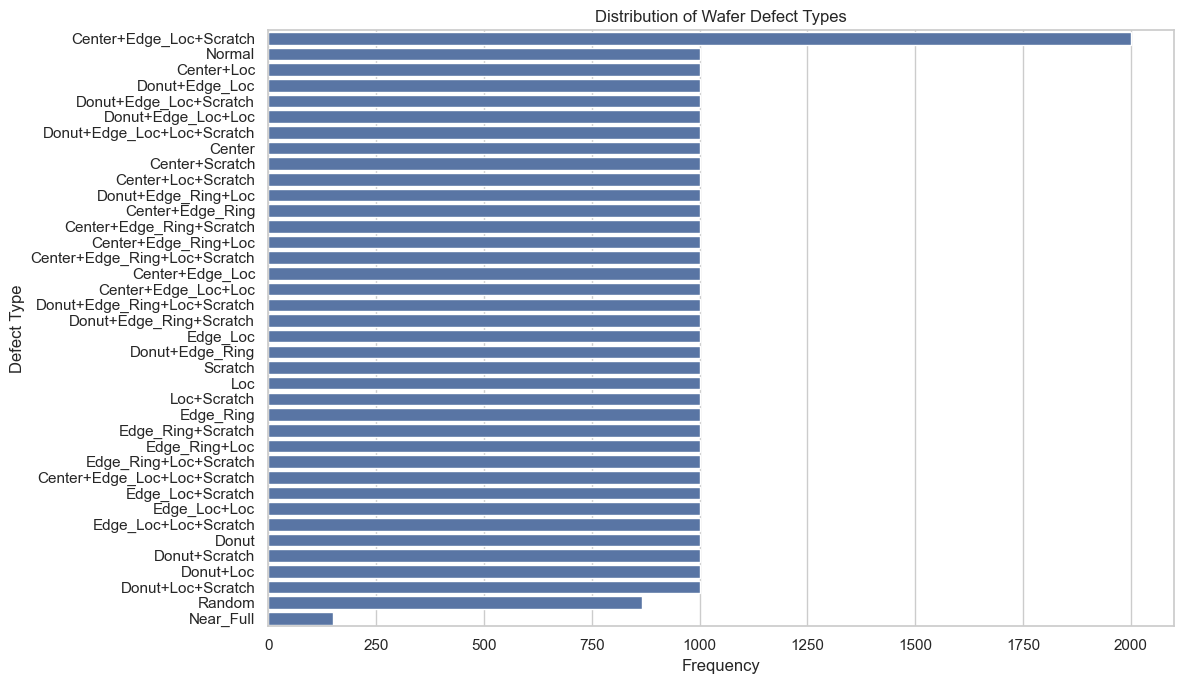

In [14]:
label_mapping = {
    "00000000": "Normal",
    "10000000": "Center",
    "01000000": "Donut",
    "00100000": "Edge_Loc",
    "00010000": "Edge_Ring",
    "00001000": "Loc",
    "00000100": "Near_Full",
    "00000010": "Scratch",
    "00000001": "Random",
    "10100000": "Center+Edge_Loc",
    "10010000": "Center+Edge_Ring",
    "10001000": "Center+Loc",
    "10000010": "Center+Scratch",
    "01100000": "Donut+Edge_Loc",
    "01010000": "Donut+Edge_Ring",
    "01001000": "Donut+Loc",
    "01000010": "Donut+Scratch",
    "00101000": "Edge_Loc+Loc",
    "00100010": "Edge_Loc+Scratch",
    "00011000": "Edge_Ring+Loc",
    "00010010": "Edge_Ring+Scratch",
    "00001010": "Loc+Scratch",
    "10101000": "Center+Edge_Loc+Loc",
    "10100010": "Center+Edge_Loc+Scratch",
    "10011000": "Center+Edge_Ring+Loc",
    "10010010": "Center+Edge_Ring+Scratch",
    "10001010": "Center+Loc+Scratch",
    "01101000": "Donut+Edge_Loc+Loc",
    "01100010": "Donut+Edge_Loc+Scratch",
    "01011000": "Donut+Edge_Ring+Loc",
    "01010010": "Donut+Edge_Ring+Scratch",
    "01001010": "Donut+Loc+Scratch",
    "00101010": "Edge_Loc+Loc+Scratch",
    "00011010": "Edge_Ring+Loc+Scratch",
    "10101010": "Center+Edge_Loc+Loc+Scratch",
    "10011010": "Center+Edge_Ring+Loc+Scratch",
    "01101010": "Donut+Edge_Loc+Loc+Scratch",
    "01011010": "Donut+Edge_Ring+Loc+Scratch",
}

# Convert one-hot vectors to string keys
label_str = ["".join(map(str, map(int, row))) for row in labels]
label_names = [label_mapping.get(key, "Unknown") for key in label_str]

# Count frequency
label_counts = Counter(label_str)

# Create DataFrame with label names
label_df = (
    pd
    .DataFrame([
        {"OneHot": k, "Count": v, "LabelName": label_mapping.get(k, "Unknown")} for k, v in label_counts.items()
    ])
    .sort_values("OneHot")
    .reset_index(drop=True)
)

# plot label distribution with seaborn
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))
sns.barplot(data=label_df, x="Count", y="LabelName", order=label_df.sort_values("Count", ascending=False)["LabelName"])
plt.xlabel("Frequency")
plt.ylabel("Defect Type")
plt.title("Distribution of Wafer Defect Types")
plt.tight_layout()
plt.show()

From the plot above, we can see that for most of the defect labels we have 1,000 images including the normal wafers. But for `Center+Edge_loc+Scratch` we have 2,000 images, for `Random` around 800 and for `Near_Full` an under representation of ~200 images.

## Images

In [15]:
# Basic summary of images array
print("Images shape:", images.shape)
print("Total entries:", images.shape[0])
print("Single image shape:", images[0].shape)
print("Dtype:", images.dtype)

# Missing data check
missing_count_images = np.isnan(images).sum()
print("Missing values (NaN) count:", missing_count_images)

# Unique values across entire images array
unique_vals_images = np.unique(images)
print("Unique values:", unique_vals_images)
print("Number of unique values:", unique_vals_images.size)

# Count images with at least one pixel value of 3
images_with_3 = np.sum(np.any(images == 3, axis=(1, 2)))
print(f"Images with at least one pixel value of 3: {images_with_3}")

# in the images that have at least one pixel value of 3, tell me the average of many pixels have the value 3
images_with_3_pixels = images[np.any(images == 3, axis=(1, 2))]
count_3_pixels = np.sum(images_with_3_pixels == 3)
average_3_pixels = count_3_pixels / images_with_3
print(f"Average number of pixels with value 3 in those images: {average_3_pixels}")

# Show a few example images (as arrays)
sample_images = images[:3]
print("Sample image arrays:")
for i, img in enumerate(sample_images, start=1):
    print(f"Image {i} shape: {img.shape}")
    print(img)

Images shape: (38015, 52, 52)
Total entries: 38015
Single image shape: (52, 52)
Dtype: int32
Missing values (NaN) count: 0
Unique values: [0 1 2 3]
Number of unique values: 4
Images with at least one pixel value of 3: 105
Average number of pixels with value 3 in those images: 2.038095238095238
Sample image arrays:
Image 1 shape: (52, 52)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Image 2 shape: (52, 52)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Image 3 shape: (52, 52)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [16]:
# make pixels with value 3 be 0
images[images == 3] = 0

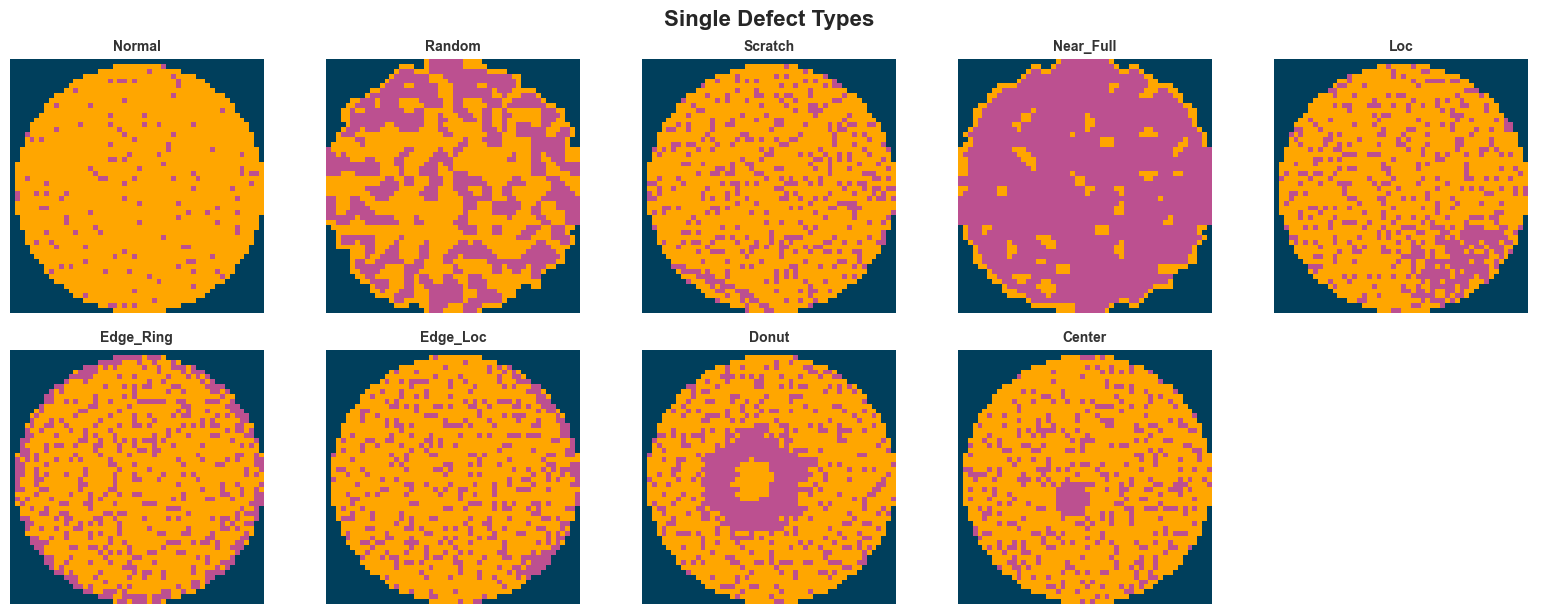

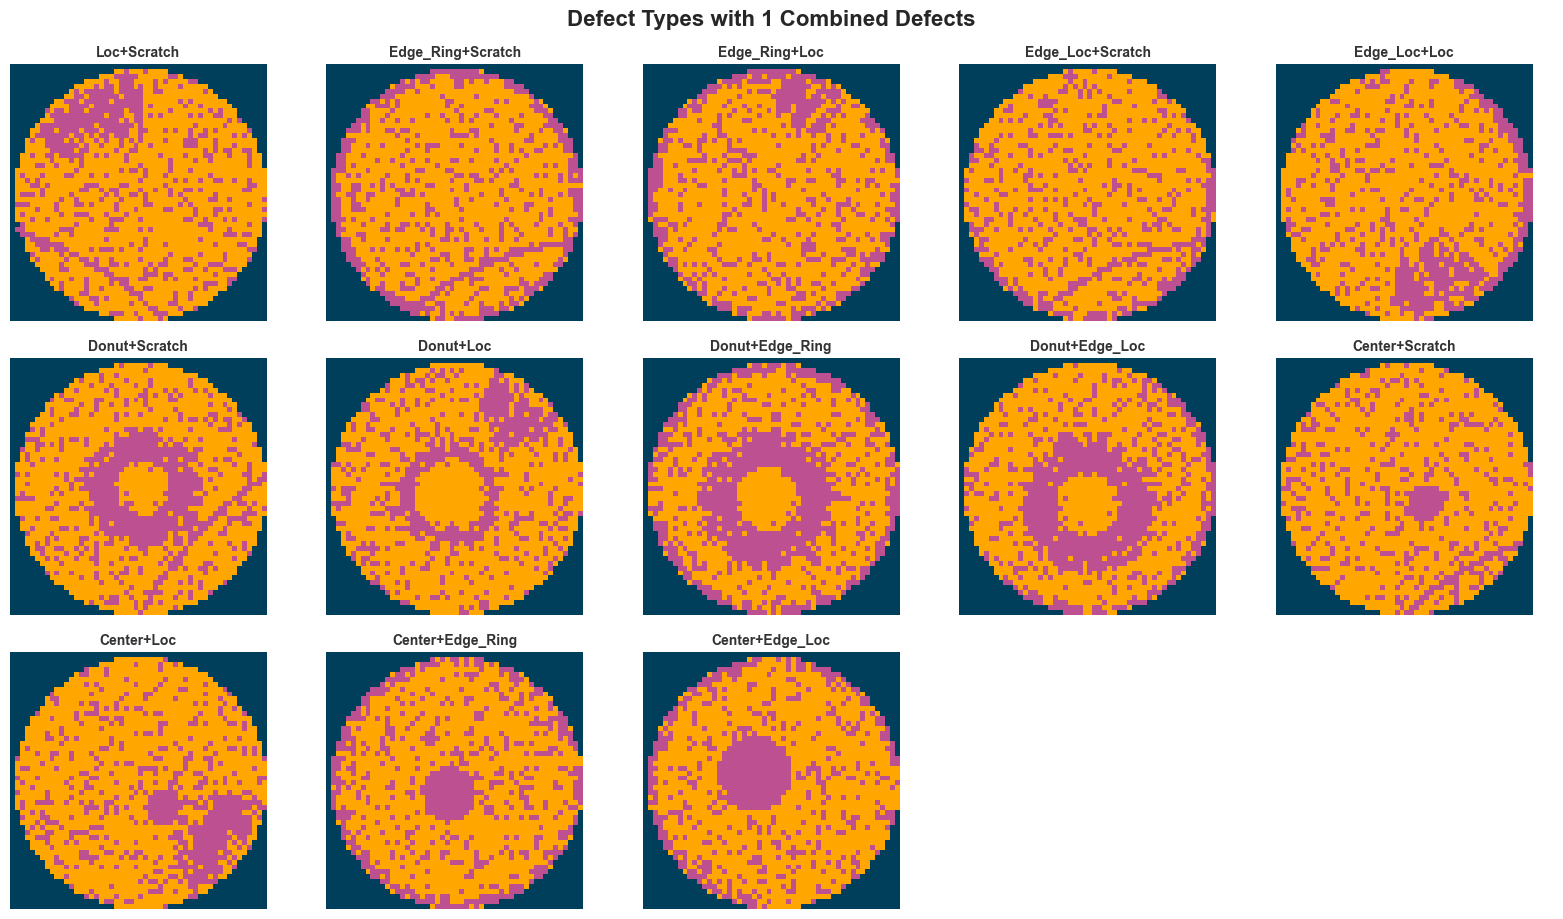

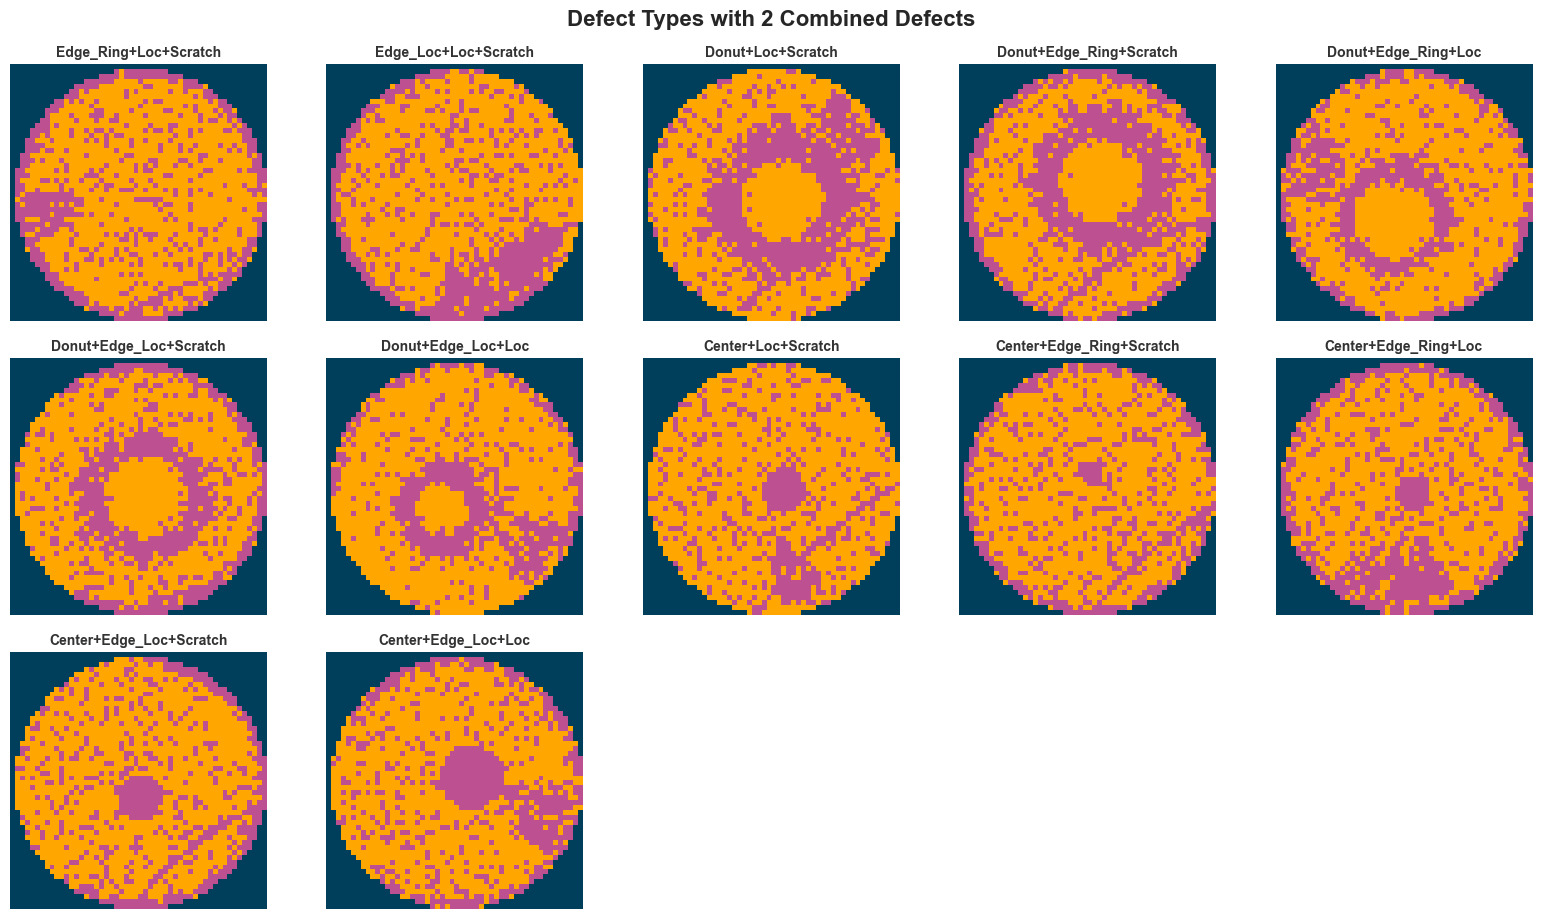

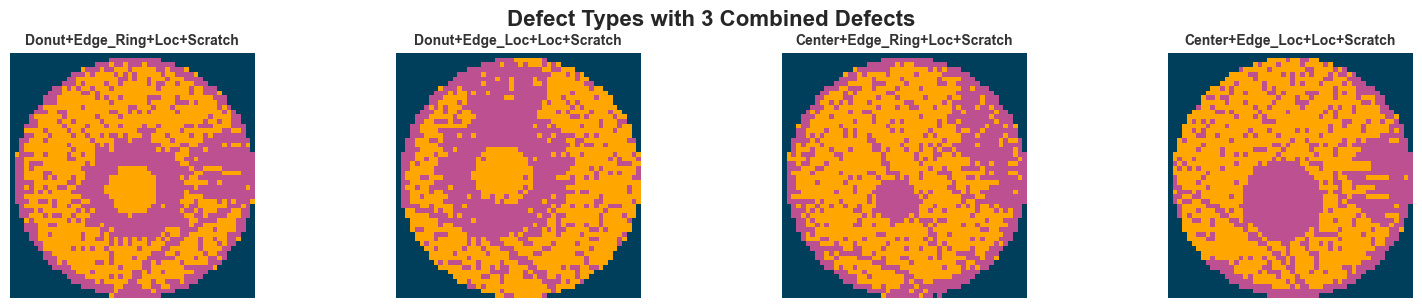

In [17]:
def convert_to_rgb(image):
    height, width = image.shape
    rgb_image = np.zeros((height, width, 3), dtype=np.uint8)
    rgb_image[image == 0] = [0, 63, 92]
    rgb_image[image == 1] = [255, 166, 0]
    rgb_image[image == 2] = [188, 80, 144]
    return rgb_image


# Separate labels by number of defects (number of '+' in label name)
unique_labels = label_df["LabelName"].tolist()

labels_by_defect_count = {0: [], 1: [], 2: [], 3: []}

for label_name in unique_labels:
    plus_count = label_name.count("+")
    labels_by_defect_count[plus_count].append(label_name)

# Plot each group separately
sns.set_theme(style="white")

for defect_count, labels_group in labels_by_defect_count.items():
    if not labels_group:
        continue

    n_labels = len(labels_group)
    n_cols = min(5, n_labels)
    n_rows = (n_labels + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
    axes = [axes] if n_labels == 1 else axes.flatten() if n_rows > 1 else axes

    for idx, label_name in enumerate(labels_group):
        label_idx = label_names.index(label_name)
        rgb_image = convert_to_rgb(images[label_idx])

        axes[idx].imshow(rgb_image)
        axes[idx].set_title(label_name, fontsize=10, fontweight="bold", color="#333333")
        axes[idx].axis("off")
        axes[idx].spines["top"].set_visible(False)
        axes[idx].spines["right"].set_visible(False)
        axes[idx].spines["bottom"].set_visible(False)
        axes[idx].spines["left"].set_visible(False)

    # Hide unused subplots
    for idx in range(n_labels, len(axes)):
        axes[idx].axis("off")

    fig.patch.set_facecolor("white")
    plt.axis("off")
    plt.tight_layout()

    # Add a suptitle for the group
    if defect_count == 0:
        fig.suptitle("Single Defect Types", fontsize=16, fontweight="bold", y=1.02)
    else:
        fig.suptitle(f"Defect Types with {defect_count} Combined Defects", fontsize=16, fontweight="bold", y=1.02)

    plt.show()

## Step 1 — Data Preprocessing

Convert each `(52, 52)` image to `(52, 52, 4)` via one-hot encoding of the 4 pixel states:
- Channel 0: blank (pixel == 0)
- Channel 1: normal die (pixel == 1)
- Channel 2: broken die (pixel == 2)
- Channel 3: undocumented state (pixel == 3, found in data exploration)

This preserves the categorical nature of the data — these are discrete states, not intensity values.

In [19]:
# One-hot encode pixel values: (N, 52, 52) -> (N, 52, 52, 3)
# Channel 0 = blank (0), Channel 1 = normal (1), Channel 2 = broken (2).
images_onehot = np.eye(3, dtype=np.float32)[images.astype(int)]

print("Original images shape:", images.shape)
print("One-hot encoded shape:", images_onehot.shape)
print("Labels shape:", labels.shape)
print("Dtype:", images_onehot.dtype)

# Verify encoding: show channel sums for first image
sample = images_onehot[0]
print("\nVerification — channel sums for first image:")
for ch in range(3):
    print(f"  Channel {ch} (pixel={ch}): {sample[:, :, ch].sum():.0f} pixels")

Original images shape: (38015, 52, 52)
One-hot encoded shape: (38015, 52, 52, 3)
Labels shape: (38015, 8)
Dtype: float32

Verification — channel sums for first image:
  Channel 0 (pixel=0): 643 pixels
  Channel 1 (pixel=1): 1441 pixels
  Channel 2 (pixel=2): 620 pixels


## Step 2 — Train / Validation / Test Split

Using iterative stratification for multi-label data. Since `sklearn`'s `train_test_split` only supports single-label stratification, we convert the 8-dim one-hot vectors to string keys and stratify on those to ensure all 38 unique patterns are represented in every split.

Split ratio: **70% train / 15% validation / 15% test**

In [20]:
# Create string keys for stratification (each unique label pattern = one stratum)
label_str_arr = np.array(["".join(map(str, map(int, row))) for row in labels])

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp, str_train, str_temp = train_test_split(
    images_onehot,
    labels,
    label_str_arr,
    test_size=0.30,
    random_state=42,
    stratify=label_str_arr,
)

# Second split: 50/50 of temp -> 15% val, 15% test
X_val, X_test, y_val, y_test, str_val, str_test = train_test_split(
    X_temp,
    y_temp,
    str_temp,
    test_size=0.50,
    random_state=42,
    stratify=str_temp,
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Val:   {X_val.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

# Verify: check that all 38 patterns are present in each split
for name, strs in [("Train", str_train), ("Val", str_val), ("Test", str_test)]:
    unique_patterns = len(set(strs))
    print(f"  {name} — unique patterns: {unique_patterns}")

# Show per-label distribution across splits
base_labels = ["Center", "Donut", "Edge_Loc", "Edge_Ring", "Loc", "Near_Full", "Scratch", "Random"]
print("\nPer-label sample counts:")
header = f"{'Label':<12} {'Train':>6} {'Val':>6} {'Test':>6}"
print(header)
for i, name in enumerate(base_labels):
    tr = y_train[:, i].sum()
    va = y_val[:, i].sum()
    te = y_test[:, i].sum()
    print(f"{name:<12} {tr:>6.0f} {va:>6.0f} {te:>6.0f}")

Train: 26610 samples
Val:   5702 samples
Test:  5703 samples
  Train — unique patterns: 38
  Val — unique patterns: 38
  Test — unique patterns: 38

Per-label sample counts:
Label         Train    Val   Test
Center         9100   1950   1950
Donut          8400   1800   1800
Edge_Loc       9100   1950   1950
Edge_Ring      8400   1800   1800
Loc           12600   2700   2700
Near_Full       104     22     23
Scratch       13300   2850   2850
Random          606    130    130


## Step 3 — Data Augmentation

Apply geometrically valid augmentations (rotations, flips, shifts) since wafer maps are rotationally symmetric. We create a `tf.data` pipeline with augmentation applied **only during training**.

We avoid elastic deformations and color jitter — the pixel values are discrete categorical states, not continuous intensities.

In [ ]:
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE


def augment(image, label):
    """Apply random geometric augmentations to a single image.

    Since pixel values are one-hot encoded categorical states,
    we only use spatial transforms (rotations, flips) that preserve
    the discrete channel structure.
    """
    # Random 90-degree rotations (k=0,1,2,3)
    k = tf.random.uniform([], 0, 4, dtype=tf.int32)
    image = tf.image.rot90(image, k=k)

    # Random horizontal and vertical flips
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)

    return image, label


def build_dataset(x, y, *, shuffle=False, augment_fn=None, batch_size=BATCH_SIZE):
    """Create a tf.data.Dataset with optional shuffling and augmentation."""
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(x), seed=42)
    if augment_fn is not None:
        ds = ds.map(augment_fn, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


# Build datasets
train_ds = build_dataset(X_train, y_train, shuffle=True, augment_fn=augment)
val_ds = build_dataset(X_val, y_val)
test_ds = build_dataset(X_test, y_test)

# Verify shapes
for batch_images, batch_labels in train_ds.take(1):
    print("Batch images shape:", batch_images.shape)
    print("Batch labels shape:", batch_labels.shape)
    print("Image value range:", batch_images.numpy().min(), "to", batch_images.numpy().max())

Batch images shape: (32, 52, 52, 3)
Batch labels shape: (32, 8)
Image value range: 0.0 to 1.0


2026-02-24 13:58:15.882317: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Step 4 — Focal Loss & Class Weights

**Focal Loss** down-weights easy/frequent examples and focuses learning on hard/rare ones. Combined with per-label weights (inversely proportional to frequency), this handles the severe imbalance between `Normal` (~1000) and `Near_Full` (~200).

$$FL(p_t) = -\alpha_t (1 - p_t)^\gamma \log(p_t)$$

- $\alpha_t$: per-label weight (higher for rare classes)
- $\gamma$: focusing parameter (typically 2.0)

In [ ]:
# Compute per-label positive weights for the 8 base defect types
# Weight = (total_neg / total_pos) for each label column
n_samples = y_train.shape[0]
pos_counts = y_train.sum(axis=0)  # shape (8,)
neg_counts = n_samples - pos_counts

# Avoid division by zero; labels with 0 positives get weight 1.0
pos_weights = np.where(pos_counts > 0, neg_counts / pos_counts, 1.0)
pos_weights_tensor = tf.constant(pos_weights, dtype=tf.float32)

print("Per-label positive weights:")
base_labels_names = ["Center", "Donut", "Edge_Loc", "Edge_Ring", "Loc", "Near_Full", "Scratch", "Random"]
for name, w, pc in zip(base_labels_names, pos_weights, pos_counts, strict=True):
    print(f"  {name:<12}  weight={w:>6.2f}  (pos_count={pc:.0f})")


class BinaryFocalLoss(tf.keras.losses.Loss):
    """Binary focal loss for multi-label classification.

    Applies focal modulation per label to down-weight easy examples
    and focus on hard/rare ones. Supports per-label positive weights.
    """

    def __init__(self, gamma=2.0, pos_weight=None, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.pos_weight = pos_weight  # shape (num_labels,)

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # Standard binary cross-entropy components
        bce_pos = -y_true * tf.math.log(y_pred)
        bce_neg = -(1.0 - y_true) * tf.math.log(1.0 - y_pred)

        # Focal modulation: (1 - p_t)^gamma
        p_t = y_true * y_pred + (1.0 - y_true) * (1.0 - y_pred)
        focal_weight = tf.pow(1.0 - p_t, self.gamma)

        # Apply per-label positive weights
        alpha = y_true * self.pos_weight + (1.0 - y_true) * 1.0 if self.pos_weight is not None else 1.0

        loss = focal_weight * alpha * (bce_pos + bce_neg)
        return tf.reduce_mean(loss, axis=-1)


focal_loss = BinaryFocalLoss(gamma=2.0, pos_weight=pos_weights_tensor)
print("\nFocal Loss initialized with gamma=2.0")

Per-label positive weights:
  Center        weight=  1.92  (pos_count=9100)
  Donut         weight=  2.17  (pos_count=8400)
  Edge_Loc      weight=  1.92  (pos_count=9100)
  Edge_Ring     weight=  2.17  (pos_count=8400)
  Loc           weight=  1.11  (pos_count=12600)
  Near_Full     weight=254.87  (pos_count=104)
  Scratch       weight=  1.00  (pos_count=13300)
  Random        weight= 42.91  (pos_count=606)

Focal Loss initialized with gamma=2.0


## Step 5 — Model 1A: Custom CNN

A lightweight CNN designed for the `(52, 52, 3)` input size:
- 4 Conv2D blocks (32 → 64 → 128 → 256 filters), each with BatchNormalization + ReLU + MaxPooling
- GlobalAveragePooling2D (reduces overfitting vs Flatten)
- Dense(128) → Dropout(0.5) → Dense(8, sigmoid)

Output: 8 independent sigmoid activations for multi-label classification.

In [ ]:
def build_custom_cnn(input_shape=(52, 52, 3), num_labels=8):
    """Build a lightweight CNN for multi-label wafer defect classification.

    Architecture:
        4 Conv blocks (32→64→128→256) with BatchNorm + ReLU + MaxPool
        GlobalAveragePooling → Dense(128) → Dropout → Dense(num_labels, sigmoid)
    """
    inputs = layers.Input(shape=input_shape, name="input_image")

    x = inputs
    for filters in [32, 64, 128, 256]:
        x = layers.Conv2D(filters, (3, 3), padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D((2, 2))(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_labels, activation="sigmoid", name="output")(x)

    return Model(inputs, outputs, name="custom_cnn")


model_cnn = build_custom_cnn()
model_cnn.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 52, 52, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 52, 52, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 52, 52, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 26, 26, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 26, 26, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 13, 13, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,264 (1.62 MB)

 Trainable params: 423,304 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

## Step 6 — Model 1B: Transfer Learning (MobileNetV2)

Project `(52, 52, 4)` → `(52, 52, 3)` with Conv2D, then resize to `(224, 224, 3)` to match MobileNetV2's expected input. Use the pre-trained ImageNet backbone as a frozen feature extractor, with a custom multi-label classification head.

**Note:** ImageNet features (edges, textures) should still transfer reasonably well to wafer map patterns.

In [30]:
TARGET_SIZE = (224, 224)


def build_mobilenet_model(input_shape=(52, 52, 3), target_size=TARGET_SIZE, num_labels=8):
    """Build a MobileNetV2 transfer learning model for multi-label classification.

    Projects (52,52,4) inputs to (52,52,3), then resizes to (224,224,3),
    then passes through a frozen MobileNetV2 backbone with a custom head.
    """
    inputs = layers.Input(shape=input_shape, name="input_image")

    # Project 4 channels to 3 for MobileNetV2 compatibility
    x = layers.Conv2D(3, (1, 1), padding="same", activation="relu")(inputs)

    # Resize to MobileNetV2-compatible dimensions
    x = layers.Resizing(target_size[0], target_size[1], interpolation="bilinear")(x)

    # Frozen MobileNetV2 backbone
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(target_size[0], target_size[1], 3),
        include_top=False,
        weights="imagenet",
    )
    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_labels, activation="sigmoid", name="output")(x)

    return Model(inputs, outputs, name="mobilenet_transfer"), base_model


model_tl, base_model_tl = build_mobilenet_model()
model_tl.summary()

# Verify frozen layers

trainable = sum(1 for layer in base_model_tl.layers if layer.trainable)
total = len(base_model_tl.layers)
print(f"\nMobileNetV2 base: {trainable}/{total} trainable layers (should be 0/{total})")

Model: "mobilenet_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 52, 52, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 52, 52, 3)      │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_2 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,988 (9.87 MB)

 Trainable params: 330,004 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


MobileNetV2 base: 0/154 trainable layers (should be 0/154)


## Step 7 — Training

Both models are trained with:
- **Loss:** Binary Focal Loss (gamma=2.0, per-label pos_weights)
- **Optimizer:** Adam (lr=1e-3)
- **Callbacks:** `ReduceLROnPlateau(patience=5)`, `EarlyStopping(patience=10, restore_best_weights=True)`
- **Metrics:** AUC (per-label average), binary accuracy
- **Epochs:** up to 100 (early stopping will cut it short)

In [31]:
EPOCHS = 100

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
]

metrics = [
    tf.keras.metrics.AUC(name="auc", multi_label=True),
    tf.keras.metrics.BinaryAccuracy(name="binary_acc"),
]

### Train Model 1A — Custom CNN

In [32]:
model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=focal_loss,
    metrics=metrics,
)

history_cnn = model_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/100
832/832 ━━━━━━━━━━━━━━━━━━━━ 29s 32ms/step - auc: 0.8383 - binary_acc: 0.7837 - loss: 0.1369 - val_auc: 0.6393 - val_binary_acc: 0.5946 - val_loss: 3.4158 - learning_rate: 0.0010
Epoch 2/100
832/832 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - auc: 0.9105 - binary_acc: 0.8614 - loss: 0.0899 - val_auc: 0.8463 - val_binary_acc: 0.7291 - val_loss: 1.2126 - learning_rate: 0.0010
Epoch 3/100
832/832 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - auc: 0.9231 - binary_acc: 0.8794 - loss: 0.0754 - val_auc: 0.9590 - val_binary_acc: 0.9168 - val_loss: 0.0503 - learning_rate: 0.0010
Epoch 4/100
832/832 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - auc: 0.9437 - binary_acc: 0.9029 - loss: 0.0655 - val_auc: 0.9438 - val_binary_acc: 0.8875 - val_loss: 0.0636 - learning_rate: 0.0010
Epoch 5/100
832/832 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step - auc: 0.9313 - binary_acc: 0.8983 - loss: 0.0617 - val_auc: 0.9456 - val_binary_acc: 0.9339 - val_loss: 0.0382 - learning_rate: 0.0010
Epoch 6/100
832/832 ━━━━━━━━━━━━━━━━━━━━ 26s 

### Train Model 1B — MobileNetV2 Transfer Learning

In [33]:
# Need fresh metrics instances (Keras metrics are stateful)
metrics_tl = [
    tf.keras.metrics.AUC(name="auc", multi_label=True),
    tf.keras.metrics.BinaryAccuracy(name="binary_acc"),
]

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=BinaryFocalLoss(gamma=2.0, pos_weight=pos_weights_tensor),
    metrics=metrics_tl,
)

# Fresh callbacks (they carry state from previous training)
callbacks_tl = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
]

history_tl = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_tl,
    verbose=1,
)

Epoch 1/100
832/832 ━━━━━━━━━━━━━━━━━━━━ 212s 252ms/step - auc: 0.8706 - binary_acc: 0.8223 - loss: 0.1170 - val_auc: 0.9471 - val_binary_acc: 0.9029 - val_loss: 0.0848 - learning_rate: 0.0010
Epoch 2/100
832/832 ━━━━━━━━━━━━━━━━━━━━ 205s 247ms/step - auc: 0.9010 - binary_acc: 0.8471 - loss: 0.1053 - val_auc: 0.9546 - val_binary_acc: 0.9005 - val_loss: 0.0754 - learning_rate: 0.0010
Epoch 3/100
832/832 ━━━━━━━━━━━━━━━━━━━━ 213s 256ms/step - auc: 0.9082 - binary_acc: 0.8529 - loss: 0.0929 - val_auc: 0.9549 - val_binary_acc: 0.8977 - val_loss: 0.0718 - learning_rate: 0.0010
Epoch 4/100
832/832 ━━━━━━━━━━━━━━━━━━━━ 205s 247ms/step - auc: 0.9102 - binary_acc: 0.8533 - loss: 0.1094 - val_auc: 0.9644 - val_binary_acc: 0.9095 - val_loss: 0.0672 - learning_rate: 0.0010
Epoch 5/100
832/832 ━━━━━━━━━━━━━━━━━━━━ 207s 249ms/step - auc: 0.9067 - binary_acc: 0.8501 - loss: 0.1046 - val_auc: 0.9538 - val_binary_acc: 0.9018 - val_loss: 0.0727 - learning_rate: 0.0010
Epoch 6/100
832/832 ━━━━━━━━━━━━━━━

## Step 8 — Phase 1 Evaluation & Comparison

Compare both models on the **test set** using:
- Training history plots (loss & AUC)
- Per-label Precision, Recall, F1
- Macro F1 summary

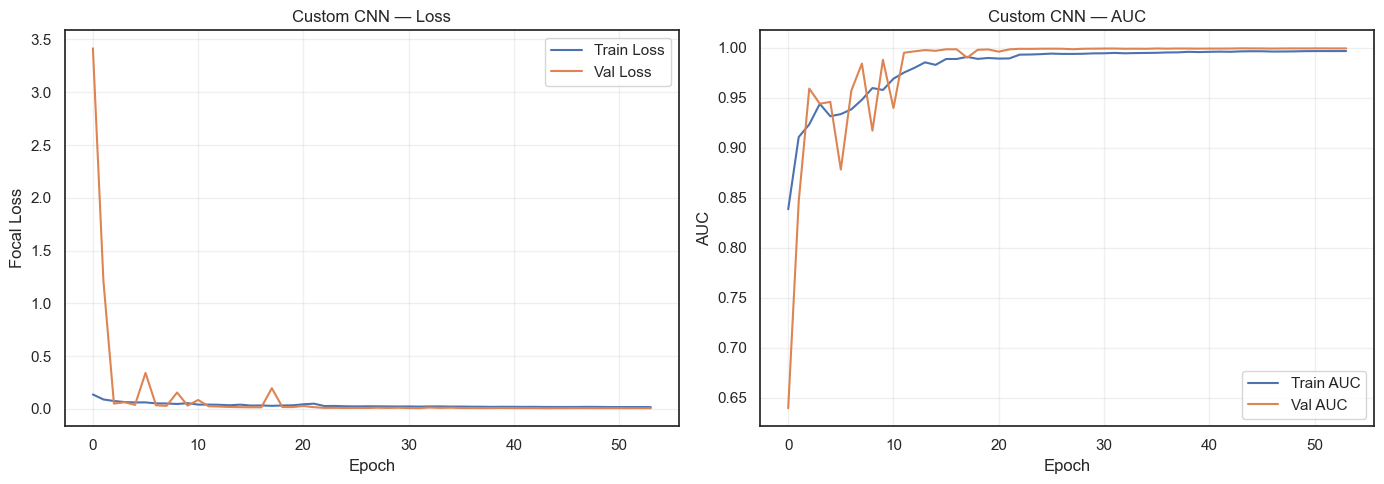

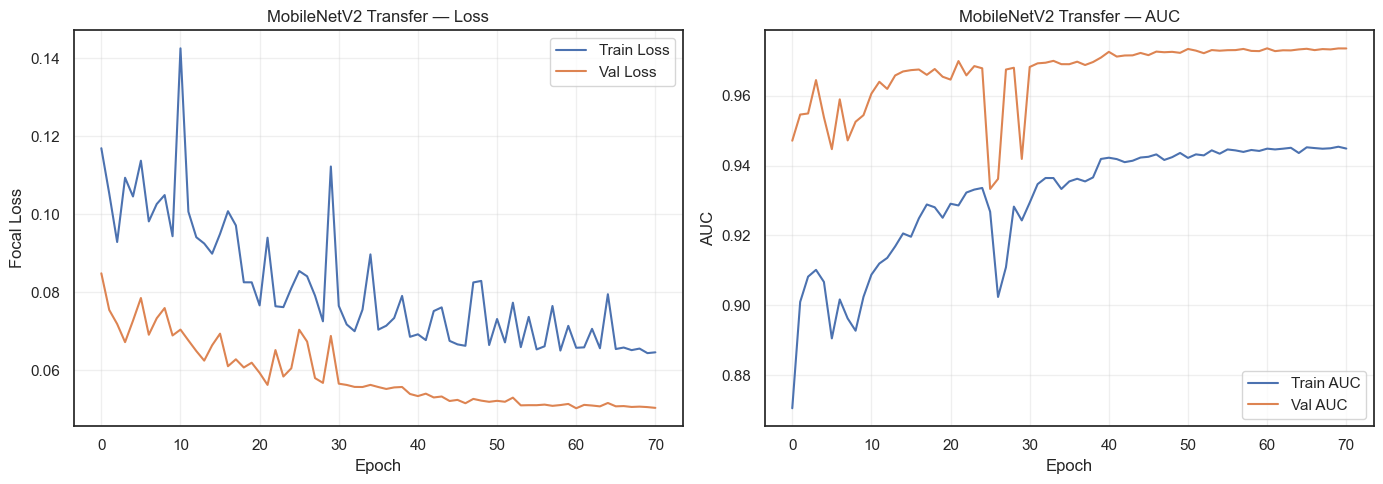

In [34]:
def plot_training_history(history, model_name):
    """Plot loss and AUC curves for training and validation."""
    _fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(history.history["loss"], label="Train Loss")
    axes[0].plot(history.history["val_loss"], label="Val Loss")
    axes[0].set_title(f"{model_name} — Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Focal Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # AUC
    axes[1].plot(history.history["auc"], label="Train AUC")
    axes[1].plot(history.history["val_auc"], label="Val AUC")
    axes[1].set_title(f"{model_name} — AUC")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("AUC")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_training_history(history_cnn, "Custom CNN")
plot_training_history(history_tl, "MobileNetV2 Transfer")

In [35]:
from sklearn.metrics import classification_report, f1_score

THRESHOLD = 0.5
base_labels_all = ["Center", "Donut", "Edge_Loc", "Edge_Ring", "Loc", "Near_Full", "Scratch", "Random"]


def evaluate_multilabel(model, dataset, y_true, model_name):
    """Evaluate a multi-label model: per-label precision/recall/F1 + macro F1."""
    y_pred_prob = model.predict(dataset, verbose=0)
    y_pred = (y_pred_prob >= THRESHOLD).astype(int)

    separator = "=" * 60
    print(f"\n{separator}")
    print(f"  {model_name} — Test Set Results (threshold={THRESHOLD})")
    print(separator)

    report = classification_report(
        y_true,
        y_pred,
        target_names=base_labels_all,
        zero_division=0,
        output_dict=True,
    )
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=base_labels_all,
            zero_division=0,
        )
    )

    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    print(f"Macro F1:    {macro_f1:.4f}")
    print(f"Weighted F1: {weighted_f1:.4f}")

    return y_pred, y_pred_prob, report


y_pred_cnn, y_prob_cnn, report_cnn = evaluate_multilabel(model_cnn, test_ds, y_test, "Custom CNN")
y_pred_tl, y_prob_tl, report_tl = evaluate_multilabel(model_tl, test_ds, y_test, "MobileNetV2 Transfer")


  Custom CNN — Test Set Results (threshold=0.5)
              precision    recall  f1-score   support

      Center       1.00      1.00      1.00      1950
       Donut       1.00      1.00      1.00      1800
    Edge_Loc       0.99      0.99      0.99      1950
   Edge_Ring       0.99      1.00      0.99      1800
         Loc       1.00      0.99      0.99      2700
   Near_Full       0.88      1.00      0.94        23
     Scratch       0.99      0.98      0.99      2850
      Random       0.97      1.00      0.98       130

   micro avg       0.99      0.99      0.99     13203
   macro avg       0.98      1.00      0.99     13203
weighted avg       0.99      0.99      0.99     13203
 samples avg       0.97      0.97      0.97     13203

Macro F1:    0.9862
Weighted F1: 0.9937

  MobileNetV2 Transfer — Test Set Results (threshold=0.5)
              precision    recall  f1-score   support

      Center       0.97      0.97      0.97      1950
       Donut       1.00      1.00     

,Defect Type,Custom CNN F1,MobileNetV2 F1
0,Center,1.0000,0.9675
1,Donut,0.9997,0.9986
2,Edge_Loc,0.9893,0.7880
3,Edge_Ring,0.9947,0.8735
4,Loc,0.9943,0.9188
5,Near_Full,0.9388,0.9020
6,Scratch,0.9882,0.8500
7,Random,0.9848,0.9886
8,MACRO AVG,0.9862,0.9109


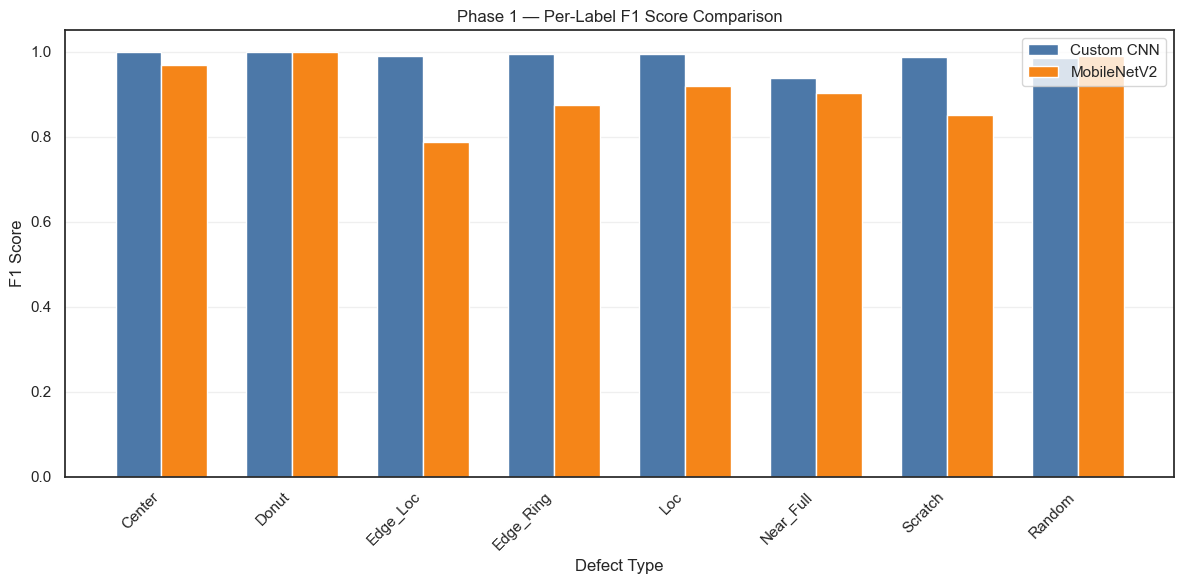

In [36]:
# Side-by-side F1 comparison per label
comparison_data = []
for label_name in base_labels_all:
    comparison_data.append({
        "Defect Type": label_name,
        "Custom CNN F1": report_cnn[label_name]["f1-score"],
        "MobileNetV2 F1": report_tl[label_name]["f1-score"],
    })

comparison_df = pd.DataFrame(comparison_data)

# Add macro averages
comparison_df = pd.concat(
    [
        comparison_df,
        pd.DataFrame([
            {
                "Defect Type": "MACRO AVG",
                "Custom CNN F1": report_cnn["macro avg"]["f1-score"],
                "MobileNetV2 F1": report_tl["macro avg"]["f1-score"],
            }
        ]),
    ],
    ignore_index=True,
)

display(
    comparison_df.style.format({"Custom CNN F1": "{:.4f}", "MobileNetV2 F1": "{:.4f}"}).highlight_max(
        subset=["Custom CNN F1", "MobileNetV2 F1"],
        axis=1,
        color="lightgreen",
    )
)

# Bar chart comparison
_fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(base_labels_all))
width = 0.35
ax.bar(
    x - width / 2, [report_cnn[lbl]["f1-score"] for lbl in base_labels_all], width, label="Custom CNN", color="#4C78A8"
)
ax.bar(
    x + width / 2, [report_tl[lbl]["f1-score"] for lbl in base_labels_all], width, label="MobileNetV2", color="#F58518"
)
ax.set_xlabel("Defect Type")
ax.set_ylabel("F1 Score")
ax.set_title("Phase 1 — Per-Label F1 Score Comparison")
ax.set_xticks(x)
ax.set_xticklabels(base_labels_all, rotation=45, ha="right")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

In [ ]:
# save models
model_cnn.save("wafer_defect_cnn.keras")
model_tl.save("wafer_defect_mobilenet_transfer.keras")
print("\nModels saved: wafer_defect_cnn.keras, wafer_defect_mobilenet_transfer.keras")


Models saved: wafer_defect_cnn.keras, wafer_defect_mobilenet_transfer.keras


# Phase 2 — Multi-Class Classification (All 38 Defect Patterns)

Reuse the best-performing Phase 1 convolutional backbone as a **frozen feature extractor** and replace the classification head with a 38-class softmax output.

**Strategy:**
1. Select the best Phase 1 model based on Macro F1
2. Freeze its conv layers, replace the head
3. Two-stage training: head-only (lr=1e-3) → fine-tune last conv blocks (lr=1e-5)

In [ ]:
# load models from .keras files
# loaded_cnn = tf.keras.models.load_model("wafer_defect_cnn.keras", custom_objects={"BinaryFocalLoss": BinaryFocalLoss})
# loaded_tl = tf.keras.models.load_model("wafer_defect_mobilenet_transfer.keras", custom_objects={"BinaryFocalLoss": BinaryFocalLoss})
# print("\nModels loaded successfully from .keras files")

## Step 9 — Encode All 38 Pattern Labels

Convert each 8-dim one-hot vector to a single integer class ID (0–37) for multi-class softmax classification. Compute class weights using `sklearn` to handle the severe imbalance.

In [39]:
from sklearn.utils.class_weight import compute_class_weight

# Build a mapping from one-hot string key → integer class ID
unique_patterns = sorted(label_mapping.keys())
pattern_to_id = {pattern: idx for idx, pattern in enumerate(unique_patterns)}
id_to_pattern = {idx: label_mapping[pattern] for pattern, idx in pattern_to_id.items()}
NUM_CLASSES = len(unique_patterns)

print(f"Number of unique defect patterns: {NUM_CLASSES}")
print("\nClass ID → Pattern Name:")
for cid, name in id_to_pattern.items():
    print(f"  {cid:>2}: {name}")

# Convert all labels to integer class IDs
y_class_all = np.array([pattern_to_id["".join(map(str, map(int, row)))] for row in labels])

# Split using the same indices — recreate from label_str_arr
y_class_train = np.array([pattern_to_id[s] for s in str_train])
y_class_val = np.array([pattern_to_id[s] for s in str_val])
y_class_test = np.array([pattern_to_id[s] for s in str_test])

print(f"\nTrain class IDs shape: {y_class_train.shape}")
print(f"Val class IDs shape:   {y_class_val.shape}")
print(f"Test class IDs shape:  {y_class_test.shape}")

# Compute class weights to handle imbalance
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=y_class_train,
)
class_weights_dict = dict(enumerate(class_weights_arr))

print("\nClass weights (top 5 highest):")
for cid, w in sorted(class_weights_dict.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {id_to_pattern[cid]:<35} weight={w:.3f}")

Number of unique defect patterns: 38

Class ID → Pattern Name:
   0: Normal
   1: Random
   2: Scratch
   3: Near_Full
   4: Loc
   5: Loc+Scratch
   6: Edge_Ring
   7: Edge_Ring+Scratch
   8: Edge_Ring+Loc
   9: Edge_Ring+Loc+Scratch
  10: Edge_Loc
  11: Edge_Loc+Scratch
  12: Edge_Loc+Loc
  13: Edge_Loc+Loc+Scratch
  14: Donut
  15: Donut+Scratch
  16: Donut+Loc
  17: Donut+Loc+Scratch
  18: Donut+Edge_Ring
  19: Donut+Edge_Ring+Scratch
  20: Donut+Edge_Ring+Loc
  21: Donut+Edge_Ring+Loc+Scratch
  22: Donut+Edge_Loc
  23: Donut+Edge_Loc+Scratch
  24: Donut+Edge_Loc+Loc
  25: Donut+Edge_Loc+Loc+Scratch
  26: Center
  27: Center+Scratch
  28: Center+Loc
  29: Center+Loc+Scratch
  30: Center+Edge_Ring
  31: Center+Edge_Ring+Scratch
  32: Center+Edge_Ring+Loc
  33: Center+Edge_Ring+Loc+Scratch
  34: Center+Edge_Loc
  35: Center+Edge_Loc+Scratch
  36: Center+Edge_Loc+Loc
  37: Center+Edge_Loc+Loc+Scratch

Train class IDs shape: (26610,)
Val class IDs shape:   (5702,)
Test class IDs shape:

## Step 10 — Phase 2 Models: Backbone Reuse

Build Phase 2 models by reusing the convolutional backbones from both Phase 1 models:
1. **Freeze** all conv layers from the Phase 1 model
2. **Replace** the `Dense(8, sigmoid)` head with `Dense(128, relu) → Dropout → Dense(38, softmax)`
3. Build separate datasets with integer class labels for `sparse_categorical_crossentropy`

In [40]:
# Build Phase 2 datasets with integer class labels
train_ds_p2 = build_dataset(X_train, y_class_train, shuffle=True, augment_fn=augment)
val_ds_p2 = build_dataset(X_val, y_class_val)
test_ds_p2 = build_dataset(X_test, y_class_test)

# Verify shapes
for batch_images, batch_labels in train_ds_p2.take(1):
    print("Phase 2 batch images shape:", batch_images.shape)
    print("Phase 2 batch labels shape:", batch_labels.shape)
    print("Sample labels:", batch_labels[:5].numpy())


def build_phase2_from_backbone(phase1_model, num_classes=NUM_CLASSES, model_name="phase2"):
    """Reuse Phase 1 conv backbone, freeze it, and add a new 38-class softmax head.

    Extracts the feature extractor (everything up to GlobalAveragePooling2D output)
    from the Phase 1 model and attaches a new classification head.
    """
    # Find the GlobalAveragePooling2D layer output in the Phase 1 model
    gap_layer = None
    for layer in phase1_model.layers:
        if isinstance(layer, layers.GlobalAveragePooling2D):
            gap_layer = layer
            break

    if gap_layer is None:
        msg = "Could not find GlobalAveragePooling2D in Phase 1 model"
        raise ValueError(msg)

    # Build feature extractor: input → GAP output
    feature_extractor = Model(
        inputs=phase1_model.input,
        outputs=gap_layer.output,
        name=f"{model_name}_backbone",
    )

    # Freeze all backbone layers
    for layer in feature_extractor.layers:
        layer.trainable = False

    # New classification head
    inputs = layers.Input(shape=phase1_model.input_shape[1:], name="input_image")
    x = feature_extractor(inputs, training=False)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="output_38")(x)

    return Model(inputs, outputs, name=model_name), feature_extractor


# Phase 2A: Custom CNN backbone → 38-class head
model_p2_cnn, backbone_cnn = build_phase2_from_backbone(model_cnn, model_name="phase2_custom_cnn")
print("Phase 2A — Custom CNN backbone:")
model_p2_cnn.summary()

# Phase 2B: MobileNetV2 backbone → 38-class head
model_p2_tl, backbone_tl = build_phase2_from_backbone(model_tl, model_name="phase2_mobilenet")
print("\nPhase 2B — MobileNetV2 backbone:")
model_p2_tl.summary()

# Verify frozen layers
for name, bb in [("CNN", backbone_cnn), ("MobileNet", backbone_tl)]:
    n_trainable = sum(1 for layer in bb.layers if layer.trainable)
    total = len(bb.layers)
    print(f"\n{name} backbone: {n_trainable}/{total} trainable layers")

Phase 2 batch images shape: (32, 52, 52, 3)
Phase 2 batch labels shape: (32,)
Sample labels: [ 6 12 28 27 24]
Phase 2A — Custom CNN backbone:


2026-02-24 19:32:55.351432: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Model: "phase2_custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 52, 52, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ phase2_custom_cnn_backbone      │ (None, 256)            │       390,336 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_38 (Dense)               │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 428,134 (1.63 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 52, 52, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ phase2_mobilenet_backbone       │ (None, 1280)           │     2,257,996 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_38 (Dense)               │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,866 (9.26 MB)

 Trainable params: 168,870 (659.65 KB)

 Non-trainable params: 2,257,996 (8.61 MB)


CNN backbone: 0/18 trainable layers

MobileNet backbone: 0/5 trainable layers


## Step 11 — Phase 2 Training (Two-Stage)

**Stage A:** Train only the new head (backbone frozen), lr=1e-3, ~30 epochs
**Stage B:** Unfreeze last 1-2 conv blocks, fine-tune end-to-end, lr=1e-5, ~30 epochs

Loss: `sparse_categorical_crossentropy` with class weights.

In [ ]:
def train_phase2_two_stage(
    model, backbone, train_ds, val_ds, class_weights, stage_a_epochs=30, stage_b_epochs=30, model_name="Phase2"
):
    """Two-stage Phase 2 training: head-only then fine-tune.

    Stage A: Backbone frozen, train only the new head (lr=1e-3).
    Stage B: Unfreeze last 2 conv blocks in backbone, fine-tune (lr=1e-5).
    """
    # ── Stage A: Head-only training ──
    separator = "=" * 60
    print(f"\n{separator}")
    print(f"  {model_name} — Stage A: Head-only training")
    print(separator)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    callbacks_a = [
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
    ]

    history_a = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=stage_a_epochs,
        callbacks=callbacks_a,
        class_weight=class_weights,
        verbose=1,
    )

    print(f"\n{separator}")
    print(f"\n{'=' * 60}")
    print(separator)
    print(f"{'=' * 60}")

    # Unfreeze last ~25% of backbone layers
    backbone_layers = backbone.layers
    unfreeze_from = int(len(backbone_layers) * 0.75)
    for layer in backbone_layers[unfreeze_from:]:
        if not isinstance(layer, layers.BatchNormalization):
            layer.trainable = True

    trainable_count = sum(1 for layer in backbone_layers if layer.trainable)
    print(f"  Unfroze layers from index {unfreeze_from}: {trainable_count}/{len(backbone_layers)} trainable")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    callbacks_b = [
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-7, verbose=1),
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
    ]

    history_b = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=stage_b_epochs,
        callbacks=callbacks_b,
        class_weight=class_weights,
        verbose=1,
    )

    return history_a, history_b

### Train Phase 2A — Custom CNN Backbone

In [42]:
hist_p2_cnn_a, hist_p2_cnn_b = train_phase2_two_stage(
    model_p2_cnn,
    backbone_cnn,
    train_ds_p2,
    val_ds_p2,
    class_weights_dict,
    model_name="Phase2 Custom CNN",
)


  Phase2 Custom CNN — Stage A: Head-only training
Epoch 1/30
832/832 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.6676 - loss: 1.1060 - val_accuracy: 0.9463 - val_loss: 0.2130 - learning_rate: 0.0010
Epoch 2/30
832/832 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9077 - loss: 0.3144 - val_accuracy: 0.9644 - val_loss: 0.1311 - learning_rate: 0.0010
Epoch 3/30
832/832 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9354 - loss: 0.2249 - val_accuracy: 0.9711 - val_loss: 0.1148 - learning_rate: 0.0010
Epoch 4/30
832/832 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9469 - loss: 0.1853 - val_accuracy: 0.9746 - val_loss: 0.1037 - learning_rate: 0.0010
Epoch 5/30
832/832 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9510 - loss: 0.1714 - val_accuracy: 0.9707 - val_loss: 0.1168 - learning_rate: 0.0010
Epoch 6/30
832/832 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9552 - loss: 0.1570 - val_accuracy: 0.9756 - val_loss: 0.1009 - learning_rate: 0.0010
Epoch 7/30
832/832 ━━━━━━━━━━━━━━━━

### Train Phase 2B — MobileNetV2 Backbone

In [43]:
hist_p2_tl_a, hist_p2_tl_b = train_phase2_two_stage(
    model_p2_tl,
    backbone_tl,
    train_ds_p2,
    val_ds_p2,
    class_weights_dict,
    model_name="Phase2 MobileNetV2",
)


  Phase2 MobileNetV2 — Stage A: Head-only training
Epoch 1/30
832/832 ━━━━━━━━━━━━━━━━━━━━ 105s 124ms/step - accuracy: 0.2303 - loss: 2.4130 - val_accuracy: 0.4819 - val_loss: 1.5985 - learning_rate: 0.0010
Epoch 2/30
832/832 ━━━━━━━━━━━━━━━━━━━━ 102s 123ms/step - accuracy: 0.3995 - loss: 1.6782 - val_accuracy: 0.5617 - val_loss: 1.2703 - learning_rate: 0.0010
Epoch 3/30
832/832 ━━━━━━━━━━━━━━━━━━━━ 98s 118ms/step - accuracy: 0.4595 - loss: 1.5063 - val_accuracy: 0.5849 - val_loss: 1.1706 - learning_rate: 0.0010
Epoch 4/30
832/832 ━━━━━━━━━━━━━━━━━━━━ 100s 121ms/step - accuracy: 0.4860 - loss: 1.4113 - val_accuracy: 0.6043 - val_loss: 1.1149 - learning_rate: 0.0010
Epoch 5/30
832/832 ━━━━━━━━━━━━━━━━━━━━ 102s 123ms/step - accuracy: 0.5050 - loss: 1.3513 - val_accuracy: 0.6333 - val_loss: 1.0446 - learning_rate: 0.0010
Epoch 6/30
832/832 ━━━━━━━━━━━━━━━━━━━━ 98s 118ms/step - accuracy: 0.5147 - loss: 1.3233 - val_accuracy: 0.6261 - val_loss: 1.0475 - learning_rate: 0.0010
Epoch 7/30
832

### Save models

In [44]:
# save models in .keras format
model_p2_cnn.save("wafer_defect_phase2_cnn.keras")
model_p2_tl.save("wafer_defect_phase2_mobilenet.keras")
print("\nPhase 2 models saved: wafer_defect_phase2_cnn.keras, wafer_defect_phase2_mobilenet.keras")


Phase 2 models saved: wafer_defect_phase2_cnn.keras, wafer_defect_phase2_mobilenet.keras


## Step 12 — Phase 2 Evaluation & Final Comparison

Evaluate both Phase 2 models on the test set with per-class F1 scores, grouped by defect count (single, double, triple, quadruple). Then produce a final summary table comparing all 4 models.

In [ ]:
from sklearn.metrics import confusion_matrix

# All 38 pattern names in class ID order
all_pattern_names = [id_to_pattern[i] for i in range(NUM_CLASSES)]


def evaluate_phase2(model, dataset, y_true, model_name):
    """Evaluate a 38-class Phase 2 model with per-class and grouped metrics."""
    y_pred = model.predict(dataset, verbose=0).argmax(axis=1)

    separator = "=" * 60
    print(f"\n{separator}")
    print(f"  {model_name} — Test Set Results (38 classes)")
    print(separator)

    report = classification_report(
        y_true,
        y_pred,
        target_names=all_pattern_names,
        zero_division=0,
        output_dict=True,
    )
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=all_pattern_names,
            zero_division=0,
        )
    )

    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    accuracy = np.mean(y_pred == y_true)
    print(f"Accuracy:    {accuracy:.4f}")
    print(f"Macro F1:    {macro_f1:.4f}")
    print(f"Weighted F1: {weighted_f1:.4f}")

    print("\nF1 by defect combination count:")
    for n_plus in range(4):
        group_labels = [name for name in all_pattern_names if name.count("+") == n_plus]
        group_f1s = [report[name]["f1-score"] for name in group_labels if name in report]
        if group_f1s:
            group_name = ["Single/Normal", "Double", "Triple", "Quadruple"][n_plus]
            print(f"  {group_name:<12} avg F1={np.mean(group_f1s):.4f}  (n={len(group_f1s)} classes)")

    return y_pred, report, macro_f1, weighted_f1


y_pred_p2_cnn, report_p2_cnn, mf1_p2_cnn, wf1_p2_cnn = evaluate_phase2(
    model_p2_cnn,
    test_ds_p2,
    y_class_test,
    "Phase2 Custom CNN",
)
y_pred_p2_tl, report_p2_tl, mf1_p2_tl, wf1_p2_tl = evaluate_phase2(
    model_p2_tl,
    test_ds_p2,
    y_class_test,
    "Phase2 MobileNetV2",
)


  Phase2 Custom CNN — Test Set Results (38 classes)
                              precision    recall  f1-score   support

                      Normal       0.99      1.00      1.00       150
                      Random       1.00      0.99      1.00       130
                     Scratch       0.99      1.00      0.99       150
                   Near_Full       0.96      1.00      0.98        23
                         Loc       0.97      0.98      0.97       150
                 Loc+Scratch       0.97      0.97      0.97       150
                   Edge_Ring       0.98      0.99      0.98       150
           Edge_Ring+Scratch       0.99      0.98      0.99       150
               Edge_Ring+Loc       0.92      0.98      0.95       150
       Edge_Ring+Loc+Scratch       0.97      0.92      0.95       150
                    Edge_Loc       0.99      0.98      0.98       150
            Edge_Loc+Scratch       0.99      0.98      0.98       150
                Edge_Loc+Loc       0

Plotting confusion matrix for best Phase 2 model: Custom CNN


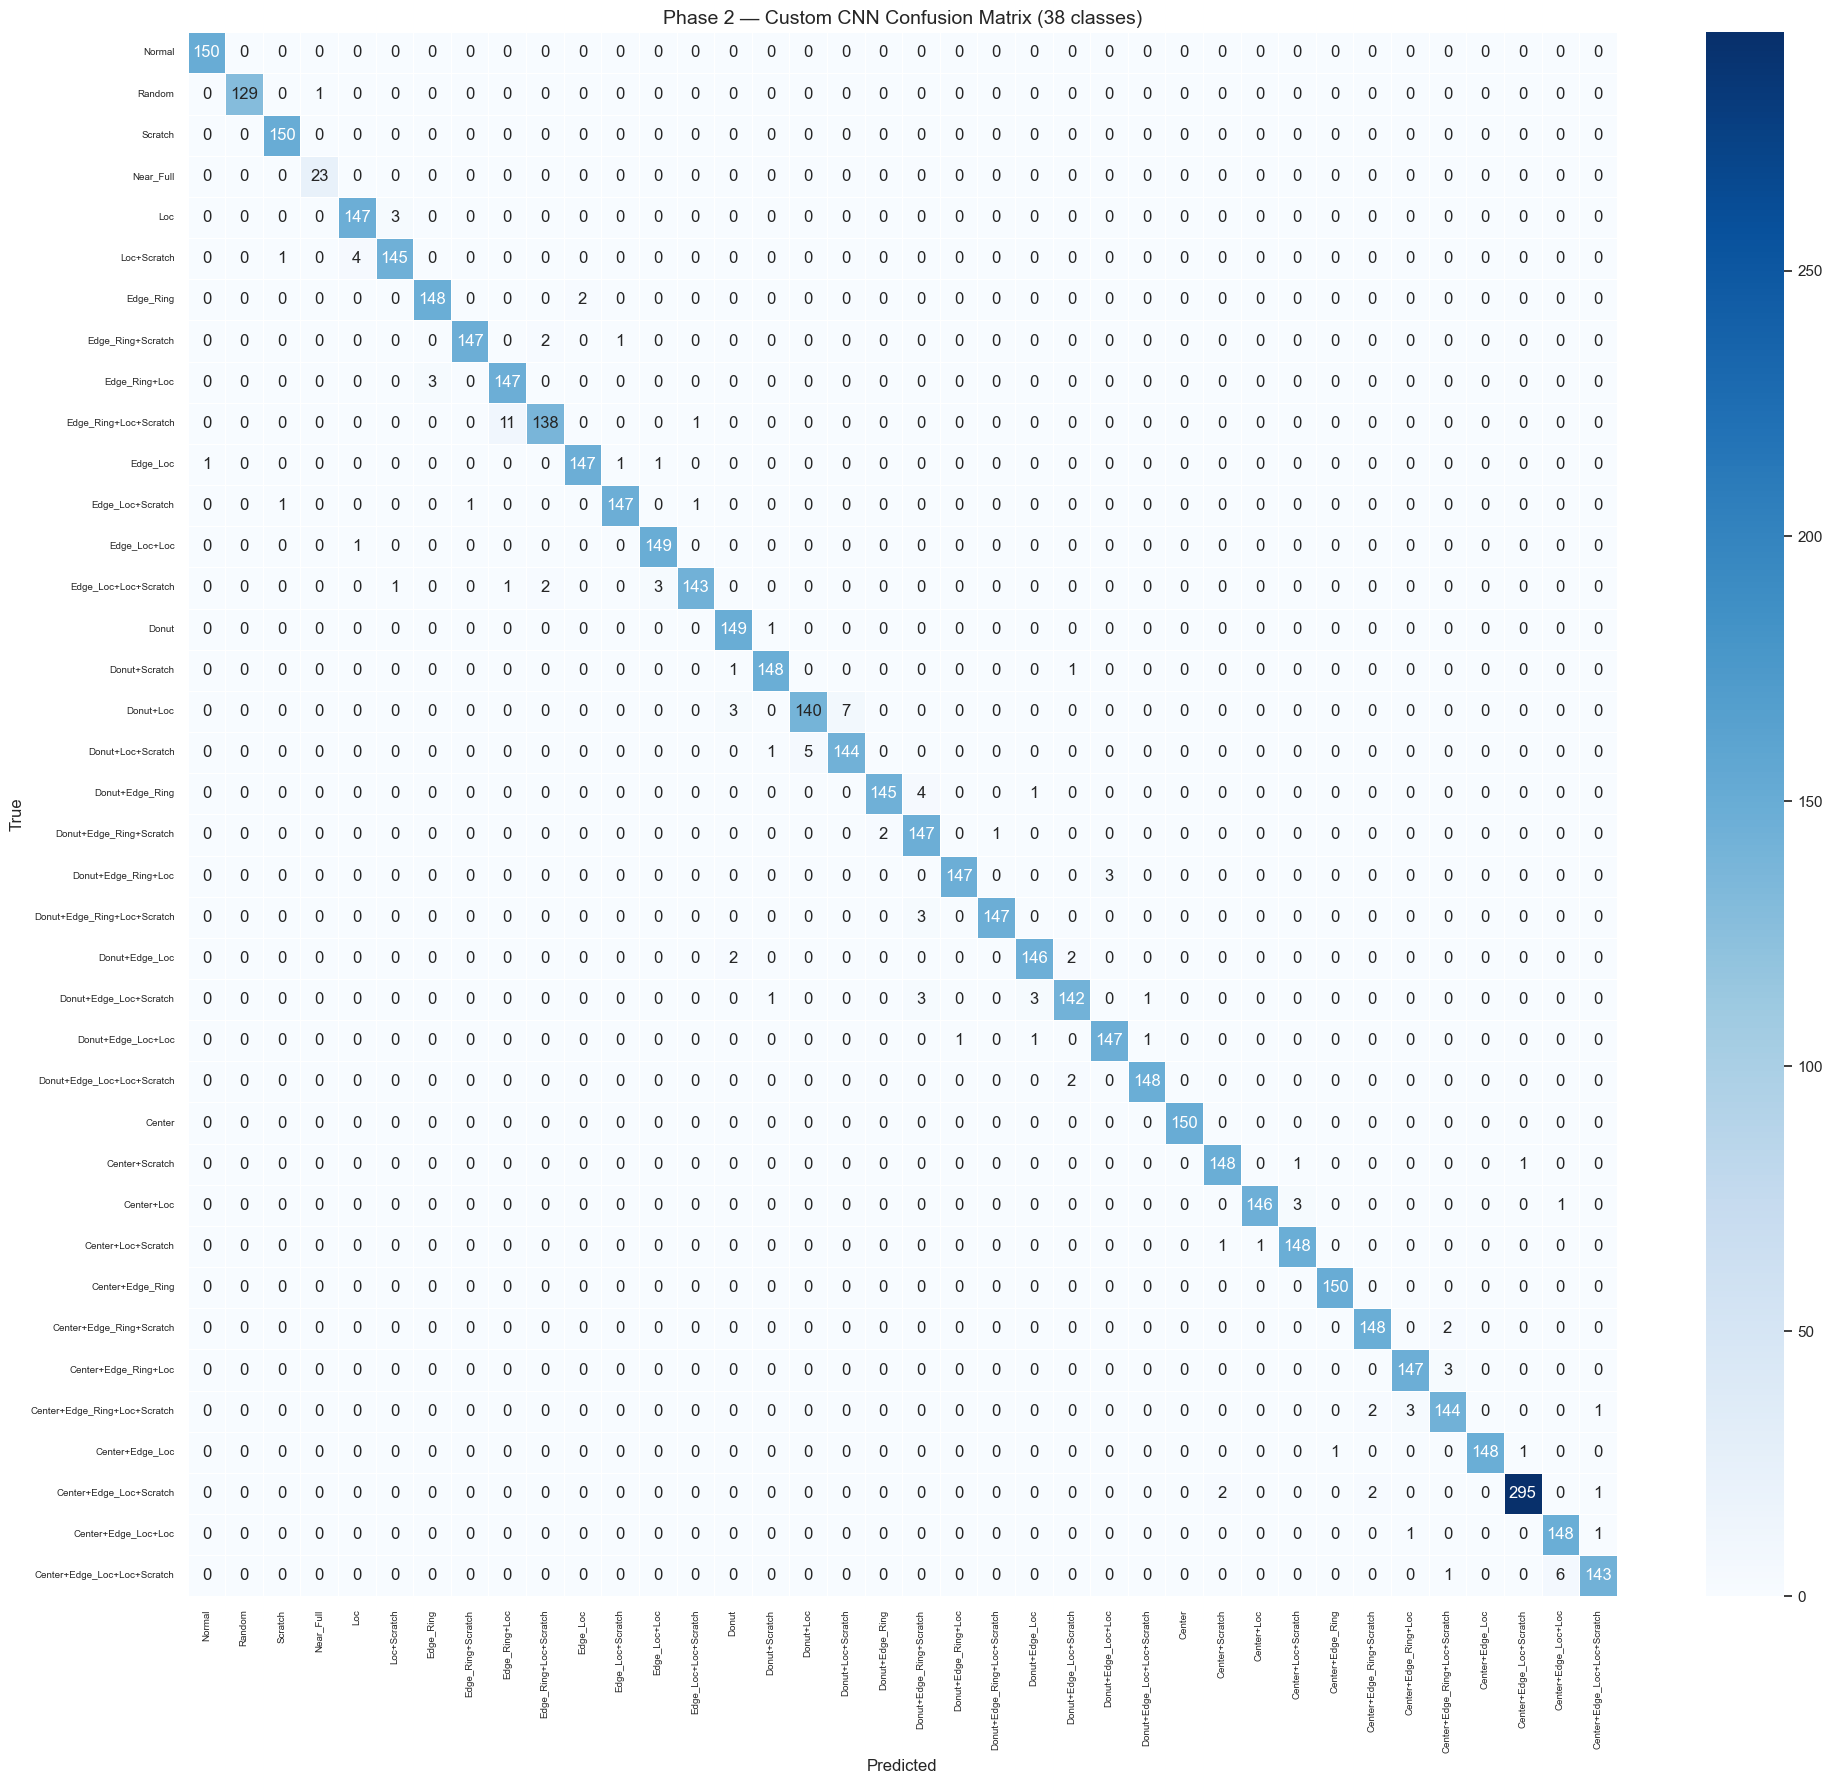

In [46]:
# Confusion matrix for the best Phase 2 model
best_p2_name = "Custom CNN" if mf1_p2_cnn >= mf1_p2_tl else "MobileNetV2"
best_p2_pred = y_pred_p2_cnn if mf1_p2_cnn >= mf1_p2_tl else y_pred_p2_tl
print(f"Plotting confusion matrix for best Phase 2 model: {best_p2_name}")

cm = confusion_matrix(y_class_test, best_p2_pred, labels=np.arange(NUM_CLASSES))

fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=all_pattern_names,
    yticklabels=all_pattern_names,
    ax=ax,
    linewidths=0.5,
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(f"Phase 2 — {best_p2_name} Confusion Matrix (38 classes)", fontsize=14)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

In [47]:
# ── Final Summary Table: All 4 Models ──
summary_data = {
    "Model": [
        "Phase 1 — Custom CNN (8-label)",
        "Phase 1 — MobileNetV2 (8-label)",
        "Phase 2 — Custom CNN (38-class)",
        "Phase 2 — MobileNetV2 (38-class)",
    ],
    "Macro F1": [
        report_cnn["macro avg"]["f1-score"],
        report_tl["macro avg"]["f1-score"],
        mf1_p2_cnn,
        mf1_p2_tl,
    ],
    "Weighted F1": [
        report_cnn["weighted avg"]["f1-score"],
        report_tl["weighted avg"]["f1-score"],
        wf1_p2_cnn,
        wf1_p2_tl,
    ],
}

summary_df = pd.DataFrame(summary_data)
display(
    summary_df.style
    .format({"Macro F1": "{:.4f}", "Weighted F1": "{:.4f}"})
    .highlight_max(subset=["Macro F1", "Weighted F1"], color="lightgreen")
    .set_caption("Final Model Comparison — All Phases")
)

,Model,Macro F1,Weighted F1
0,Phase 1 — Custom CNN (8-label),0.9862,0.9937
1,Phase 1 — MobileNetV2 (8-label),0.9109,0.8972
2,Phase 2 — Custom CNN (38-class),0.9774,0.9776
3,Phase 2 — MobileNetV2 (38-class),0.9726,0.9730
